# Part 2D — Final Evaluation: All Models Compared
**Unit:** CIS143-6 Applications of AI  
> Run after all previous notebooks. Loads all saved models from Google Drive.
> Produces: comparison table, precision-recall curves, confusion matrices, bar chart, error analysis.

## 0. Setup & Load All Models

In [1]:
import os, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
from tensorflow.keras.applications import ConvNeXtSmall
from scipy.stats import wilcoxon

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0-dev0+selfbuilt


In [2]:
import google.colab as _colab_mod
IN_COLAB = not getattr(_colab_mod, '_IS_LOCAL_STUB', False)

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/brain_tumour_mri')
    DATA_DIR = Path('/content/brain_tumour_data')
    if not DATA_DIR.exists():
        shutil.copytree(DRIVE_DIR / 'dataset', DATA_DIR)
else:
    import kagglehub
    DRIVE_DIR = Path('../models')
    DATA_DIR = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
    print("Dataset at:", DATA_DIR)

DRIVE_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR = DATA_DIR / 'Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
print("Model folder:", DRIVE_DIR)

Dataset at: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2
Model folder: ../models


In [ ]:
records = []
for cls in CLASSES:
    for img_path in (TRAIN_DIR / cls).glob('*.jpg'):
        records.append({'filepath': str(img_path), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

val_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

CLASS_NAMES = list(test_gen.class_indices.keys())
y_true = test_gen.classes
y_true_bin = label_binarize(y_true, classes=list(range(4)))

def otsu_rescale(img_array):
    img = img_array / 255.0
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)
        mask = clean_mask
    return img * np.stack([mask / 255.0] * 3, axis=-1).astype(np.float32)

seg_test_datagen = ImageDataGenerator(preprocessing_function=otsu_rescale)
seg_test_gen = seg_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

effnet_test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)
effnet_test_gen = effnet_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print(f'Test set: {len(test_df)} images  |  Classes: {CLASS_NAMES}')

convnext_test_datagen = ImageDataGenerator(preprocessing_function=convnext_preprocess)
convnext_test_gen = convnext_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=16, class_mode='categorical', shuffle=False)


Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Test set: 840 images  |  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Found 840 validated image filenames belonging to 4 classes.


In [ ]:
def otsu_rescale(img_array):
    img = img_array / 255.0
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)
        mask = clean_mask
    return img * np.stack([mask / 255.0] * 3, axis=-1).astype(np.float32)

seg_test_gen = ImageDataGenerator(preprocessing_function=otsu_rescale).flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

effnet_test_gen = ImageDataGenerator(preprocessing_function=effnet_preprocess).flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

convnext_test_gen = ImageDataGenerator(preprocessing_function=convnext_preprocess).flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print('All test generators ready.')

Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
All test generators ready.


In [ ]:
model_files = {
    'Baseline CNN':          'baseline_cnn.keras',
    'ANN':                   'ann_model.keras',
    'CNN Exp A':             'cnn_expA_best.keras',
    'CNN Exp B (Otsu)':      'cnn_expB_best.keras',
    'EfficientNetB0 Exp A':  'effnet_frozen.keras',
    'EfficientNetB0 Exp B':  'effnet_finetuned.keras',
    'ConvNeXtSmall Exp A':   'convnext_frozen.keras',
    'ConvNeXtSmall Exp B':   'convnext_finetuned.keras',
}

def gen_for(name):
    if 'Otsu'        in name: return seg_test_gen
    if 'EfficientNet' in name: return effnet_test_gen
    if 'ConvNeXt'    in name: return convnext_test_gen
    return test_gen

all_probs   = {}
all_preds   = {}
models_loaded = {}
GRADCAM_KEEP = {'Baseline CNN', 'EfficientNetB0 Exp A', 'ConvNeXtSmall Exp A'}

for name, fname in model_files.items():
    path = DRIVE_DIR / fname
    if not path.exists():
        print(f'MISSING: {name} ({path})')
        continue
    print(f'Loading {name} ...', end=' ', flush=True)
    model = tf.keras.models.load_model(str(path), compile=False)
    gen = gen_for(name)
    gen.reset()
    probs = model.predict(gen, verbose=0)
    all_probs[name] = probs
    all_preds[name] = probs.argmax(axis=1)
    if name in GRADCAM_KEEP:
        models_loaded[name] = model
    else:
        del model
        import gc; gc.collect()
    print('done')

print(f'Predictions collected for {len(all_probs)} models.')

Loading Baseline CNN ... 

I0000 00:00:1779236130.298811      29 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14534 MB memory:  -> device: 0, name: AMD Radeon Graphics, pci bus id: 0000:03:00.0
I0000 00:00:1779236133.150624     205 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


done
Loading ANN ... done
Loading CNN Exp A ... done
Loading CNN Exp B (Otsu) ... done
Loading EfficientNetB0 Exp A ... done
Loading EfficientNetB0 Exp B ... done
Loading ConvNeXtSmall Exp A ... done
Loading ConvNeXtSmall Exp B ... done
Predictions collected for 8 models.


In [ ]:
print('Models with predictions:', list(all_probs.keys()))

Models with predictions: ['Baseline CNN', 'ANN', 'CNN Exp A', 'CNN Exp B (Otsu)', 'EfficientNetB0 Exp A', 'EfficientNetB0 Exp B', 'ConvNeXtSmall Exp A', 'ConvNeXtSmall Exp B']


## 1. Final Comparison Table

In [7]:
from sklearn.metrics import accuracy_score

results = {}
for name, preds in all_preds.items():
    rep = classification_report(y_true, preds, output_dict=True)
    acc = accuracy_score(y_true, preds)
    results[name] = {
        'Accuracy':        round(acc, 4),
        'Macro Precision': round(rep['macro avg']['precision'], 4),
        'Macro Recall':    round(rep['macro avg']['recall'], 4),
        'Macro F1':        round(rep['macro avg']['f1-score'], 4),
    }

results_df = pd.DataFrame(results).T
print('=== FINAL MODEL COMPARISON ===')
print(results_df.to_string())
results_df.style.highlight_max(
    props="background-color: lightgreen; color: black;", axis=0
)

=== FINAL MODEL COMPARISON ===
                      Accuracy  Macro Precision  Macro Recall  Macro F1
Baseline CNN            0.8583           0.8607        0.8583    0.8549
ANN                     0.6036           0.6197        0.6036    0.5404
CNN Exp A               0.8083           0.8387        0.8083    0.8060
CNN Exp B (Otsu)        0.9095           0.9159        0.9095    0.9102
EfficientNetB0 Exp A    0.9131           0.9149        0.9131    0.9129
EfficientNetB0 Exp B    0.8988           0.8985        0.8988    0.8973
ConvNeXtSmall Exp A     0.9262           0.9270        0.9262    0.9260
ConvNeXtSmall Exp B     0.9274           0.9284        0.9274    0.9259


,Accuracy,Macro Precision,Macro Recall,Macro F1
Baseline CNN,0.858300,0.860700,0.858300,0.854900
ANN,0.603600,0.619700,0.603600,0.540400
CNN Exp A,0.808300,0.838700,0.808300,0.806000
CNN Exp B (Otsu),0.909500,0.915900,0.909500,0.910200
EfficientNetB0 Exp A,0.913100,0.914900,0.913100,0.912900
EfficientNetB0 Exp B,0.898800,0.898500,0.898800,0.897300
ConvNeXtSmall Exp A,0.926200,0.927000,0.926200,0.926000
ConvNeXtSmall Exp B,0.927400,0.928400,0.927400,0.925900


## 2. Precision-Recall Curves — All Models

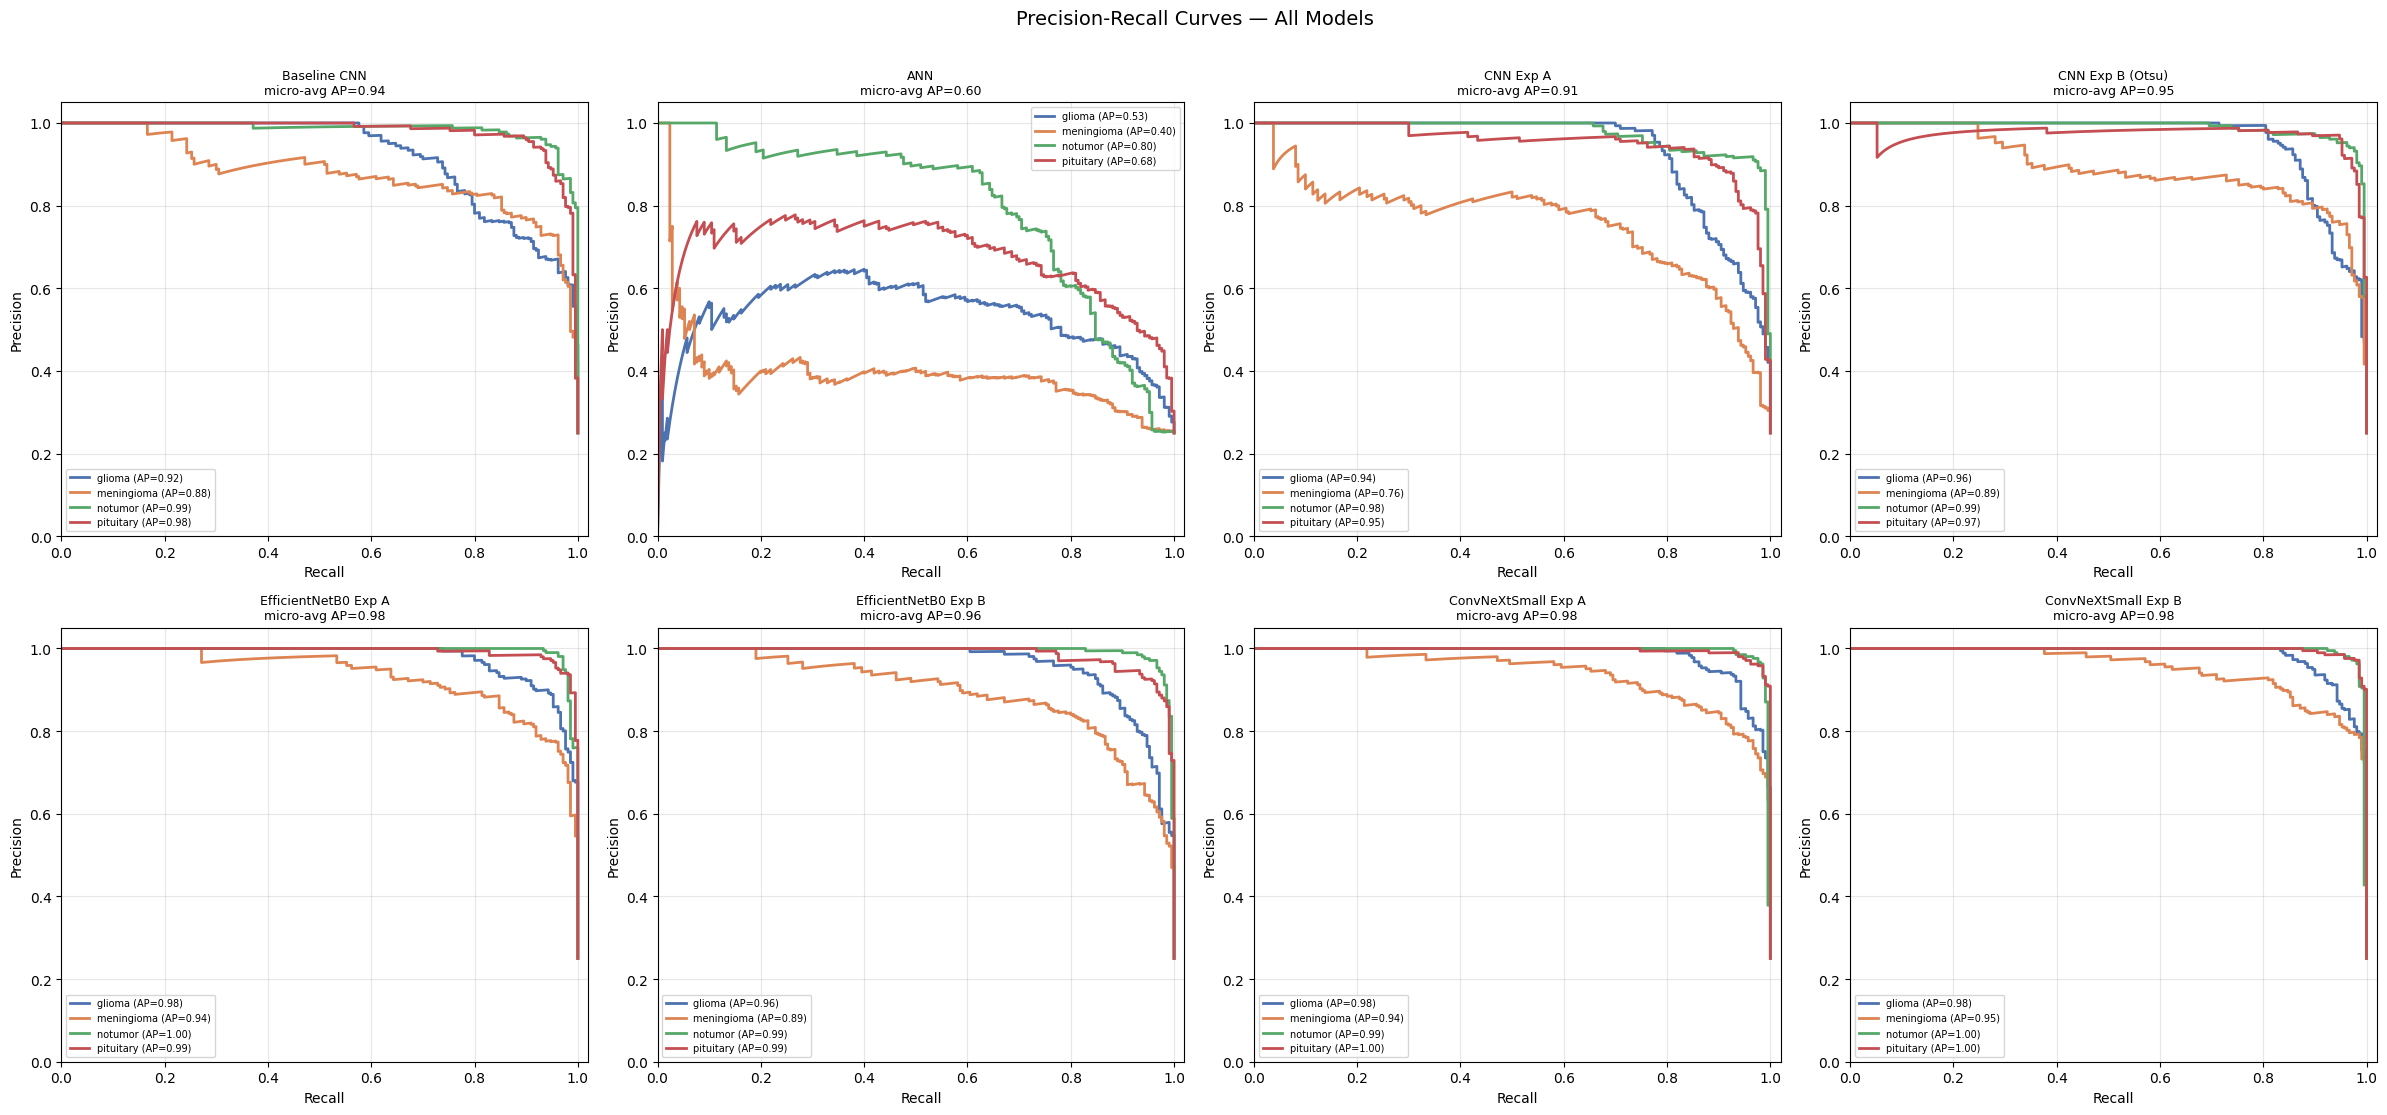

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
colours_cls = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (model_name, probs) in zip(axes.flat, all_probs.items()):
    micro_ap_vals = []
    for i, cls in enumerate(CLASS_NAMES):
        p, r, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        ap = average_precision_score(y_true_bin[:, i], probs[:, i])
        micro_ap_vals.append(ap)
        ax.plot(r, p, label=f'{cls} (AP={ap:.2f})', color=colours_cls[i], lw=2)
    ax.set_title(f'{model_name}\nmicro-avg AP={np.mean(micro_ap_vals):.2f}', fontsize=9)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05)

plt.suptitle('Precision-Recall Curves — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 3. Side-by-Side Confusion Matrices

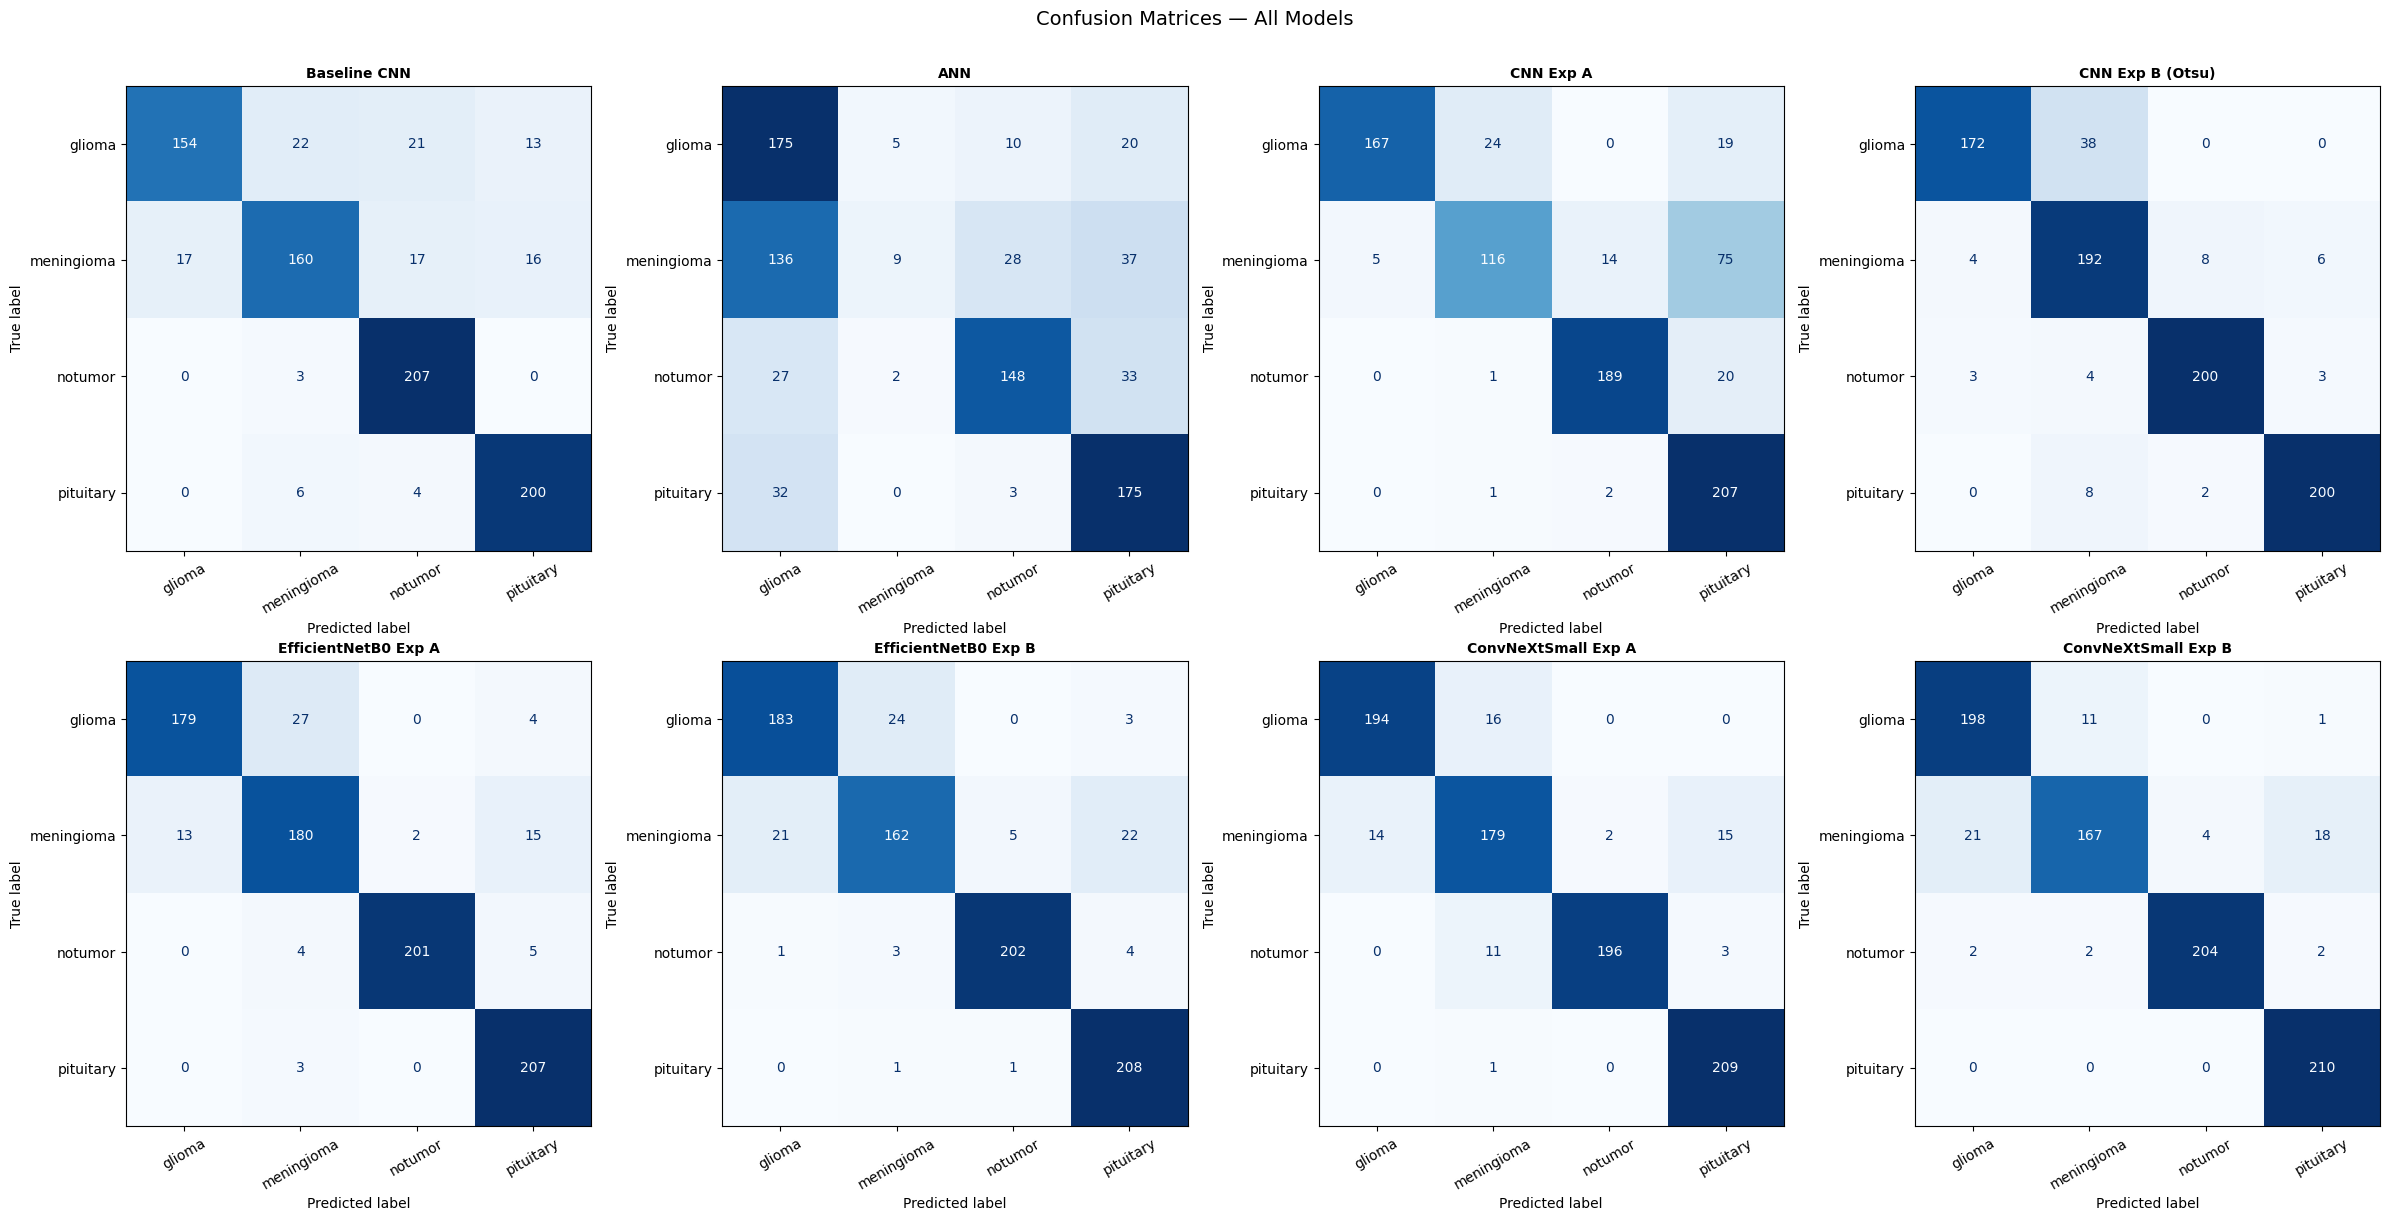

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for ax, (model_name, preds) in zip(axes.flat, all_preds.items()):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(model_name, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


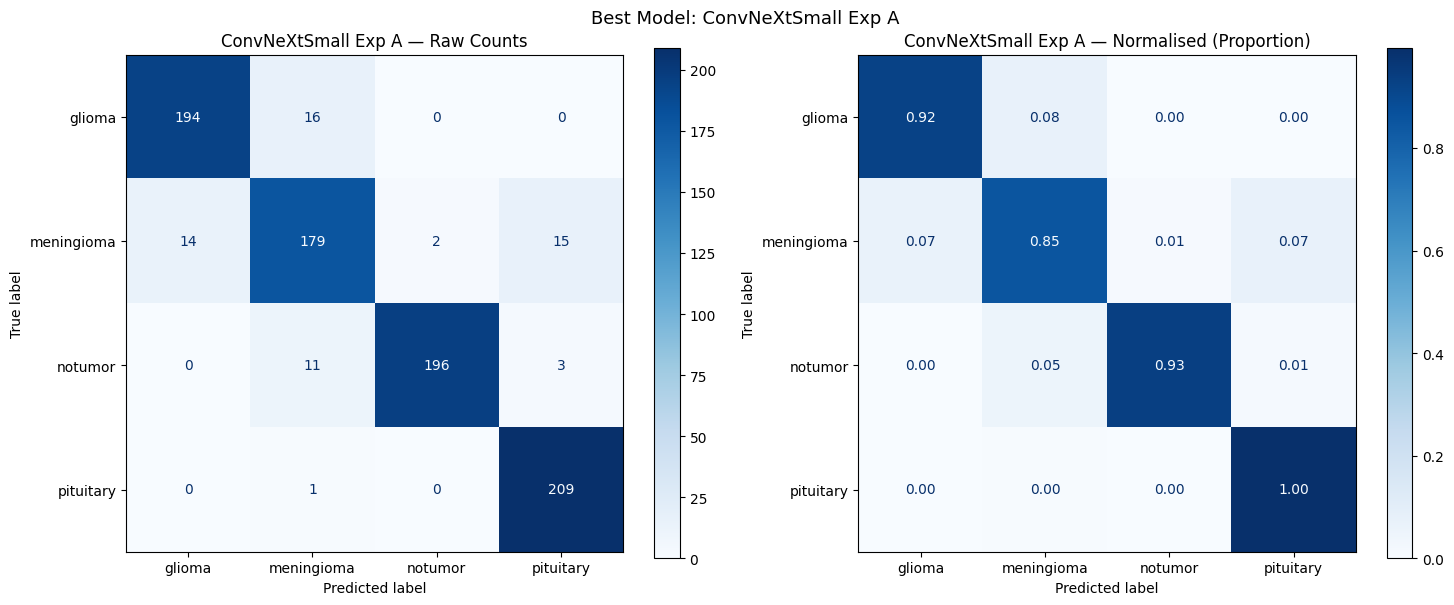

In [ ]:
best_name = results_df['Macro F1'].idxmax()
best_preds = all_preds[best_name]
cm_best = confusion_matrix(y_true, best_preds)
cm_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(cm_best, display_labels=CLASS_NAMES).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title(f'{best_name} — Raw Counts')

ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(ax=ax2, cmap='Blues', values_format='.2f')
ax2.set_title(f'{best_name} — Normalised (Proportion)')

plt.suptitle(f'Best Model: {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Error Analysis — Best Model

In [ ]:
from PIL import Image as PILImage

best_gen = (seg_test_gen if 'Otsu' in best_name
            else effnet_test_gen if 'EfficientNet' in best_name
            else convnext_test_gen if 'ConvNeXt' in best_name
            else test_gen)
best_gen.reset()
best_probs = all_probs[best_name]
best_preds_arr = all_preds[best_name]
filepaths = best_gen.filepaths

misclassified = [
    (filepaths[i], y_true[i], best_preds_arr[i], best_probs[i].max())
    for i in range(len(y_true))
    if y_true[i] != best_preds_arr[i]
]
print(f'Misclassified by {best_name}: {len(misclassified)} / {len(y_true)} '
      f'({len(misclassified)/len(y_true)*100:.1f}%)')

pair_counts = {}
for _, t, p, _ in misclassified:
    key = f'{CLASS_NAMES[t]} → {CLASS_NAMES[p]}'
    pair_counts[key] = pair_counts.get(key, 0) + 1
print('\nMost common confusion pairs:')
for pair, cnt in sorted(pair_counts.items(), key=lambda x: -x[1])[:8]:
    print(f'  {pair}: {cnt}')

Misclassified by ConvNeXtSmall Exp A: 62 / 840 (7.4%)

Most common confusion pairs:
  glioma → meningioma: 16
  meningioma → pituitary: 15
  meningioma → glioma: 14
  notumor → meningioma: 11
  notumor → pituitary: 3
  meningioma → notumor: 2
  pituitary → meningioma: 1


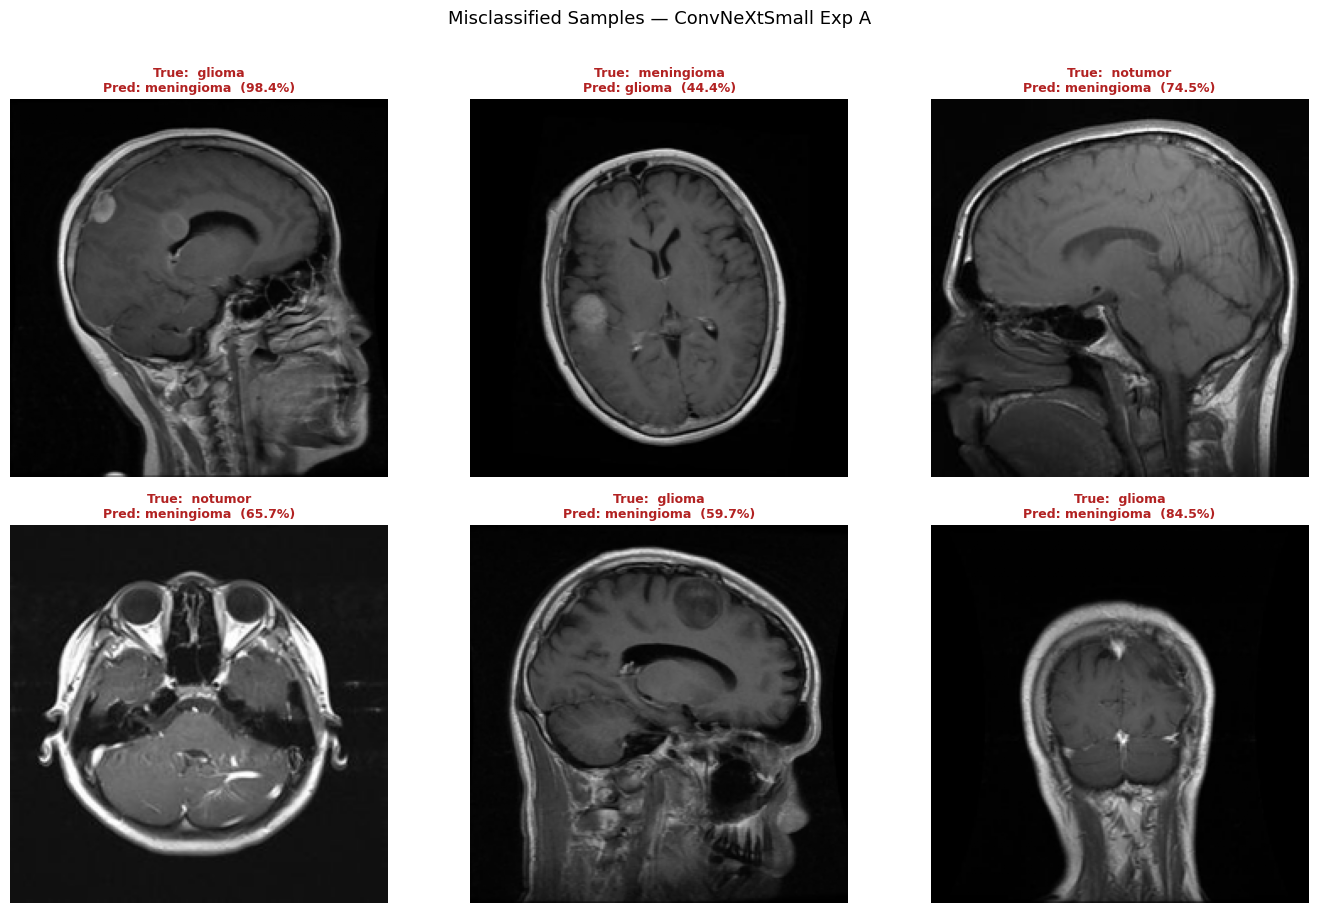

In [12]:
samples = random.sample(misclassified, min(6, len(misclassified)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (path, true_idx, pred_idx, conf) in zip(axes.flat, samples):
    img = PILImage.open(path).resize((224, 224))
    ax.imshow(img, cmap='gray')
    ax.set_title(
        f'True:  {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}  ({conf:.1%})',
        fontsize=9, color='firebrick', fontweight='bold'
    )
    ax.axis('off')

plt.suptitle(f'Misclassified Samples — {best_name}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Macro F1 Comparison Bar Chart

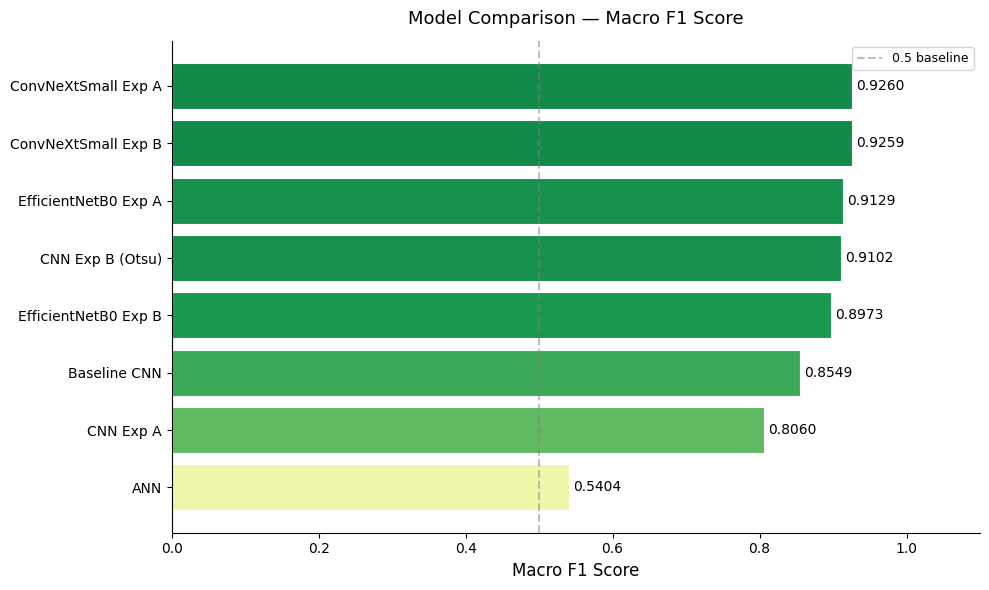


Best model: ConvNeXtSmall Exp A
Best Macro F1: 0.926
Best Accuracy: 0.9262


In [13]:
sorted_df = results_df.sort_values('Macro F1')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_df.index, sorted_df['Macro F1'],
               color=plt.cm.RdYlGn(sorted_df['Macro F1'].values),
               edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_title('Model Comparison — Macro F1 Score', fontsize=13, pad=12)
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5 baseline')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nBest model: {best_name}')
print(f'Best Macro F1: {results_df.loc[best_name, "Macro F1"]}')
print(f'Best Accuracy: {results_df.loc[best_name, "Accuracy"]}')

## 6. Per-Class F1 Heatmap — All Models

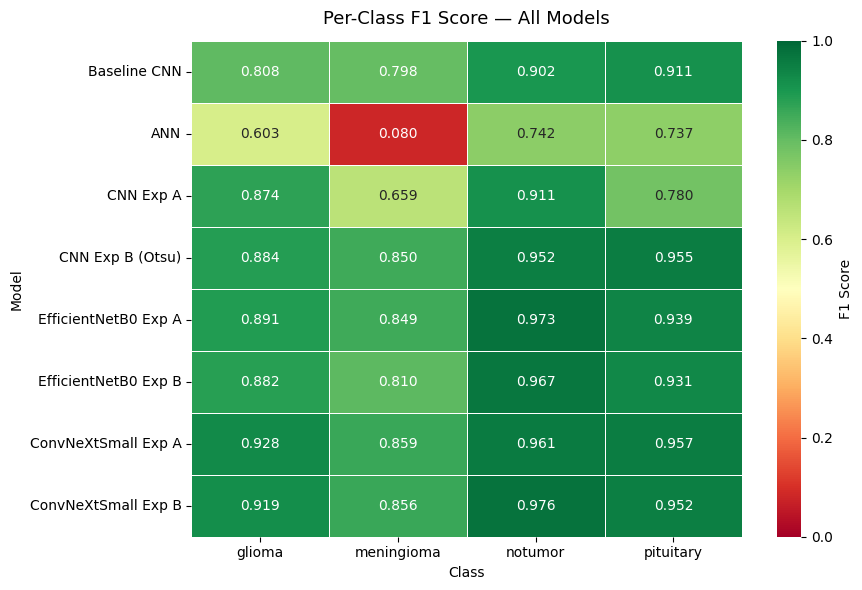

In [14]:
perclass_f1 = {}
for name, preds in all_preds.items():
    rep = classification_report(y_true, preds, target_names=CLASS_NAMES, output_dict=True)
    perclass_f1[name] = {cls: rep[cls]['f1-score'] for cls in CLASS_NAMES}

pc_df = pd.DataFrame(perclass_f1).T
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Class F1 Score — All Models', fontsize=13, pad=12)
ax.set_xlabel('Class')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## 7. GradCAM — Model Interpretability (EfficientNetB0 vs Baseline CNN)
GradCAM highlights the image regions that most influenced each prediction.

In [ ]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)
    sub_models = [l for l in model.layers if isinstance(l, tf.keras.Model)]

    if sub_models:
        base = sub_models[0]
        last_conv = next(
            (l.name for l in reversed(base.layers)
             if isinstance(l, tf.keras.layers.Conv2D)), None
        )
        if last_conv is None:
            raise ValueError('No Conv2D layer in base model — GradCAM not applicable')
        
        feat_extractor = tf.keras.models.Model(
            inputs=base.inputs,
            outputs=[base.get_layer(last_conv).output, base.output]
        )

        post_base, after = [], False
        for layer in model.layers:
            if layer.name == base.name:
                after = True; continue
            if after:
                post_base.append(layer)

        with tf.GradientTape() as tape:
            conv_outputs, x = feat_extractor(img_tensor)
            for layer in post_base:
                x = layer(x)
            predictions = x
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
    else:
        last_conv = next(
            (l.name for l in reversed(model.layers)
              if isinstance(l, tf.keras.layers.Conv2D)), None
        )
        if last_conv is None:
            raise ValueError("No Conv2D in model — GradCAM not applicable")

        with tf.GradientTape() as tape:
            x = img_tensor
            conv_outputs = None
            for layer in model.layers:
                if layer.name == last_conv:
                    x = layer(x)
                    conv_outputs = x
                    tape.watch(conv_outputs)
                else:
                    x = layer(x)
            predictions = x
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), last_conv

def overlay_heatmap(img_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap_color + (1 - alpha) * img_rgb).astype(np.uint8)

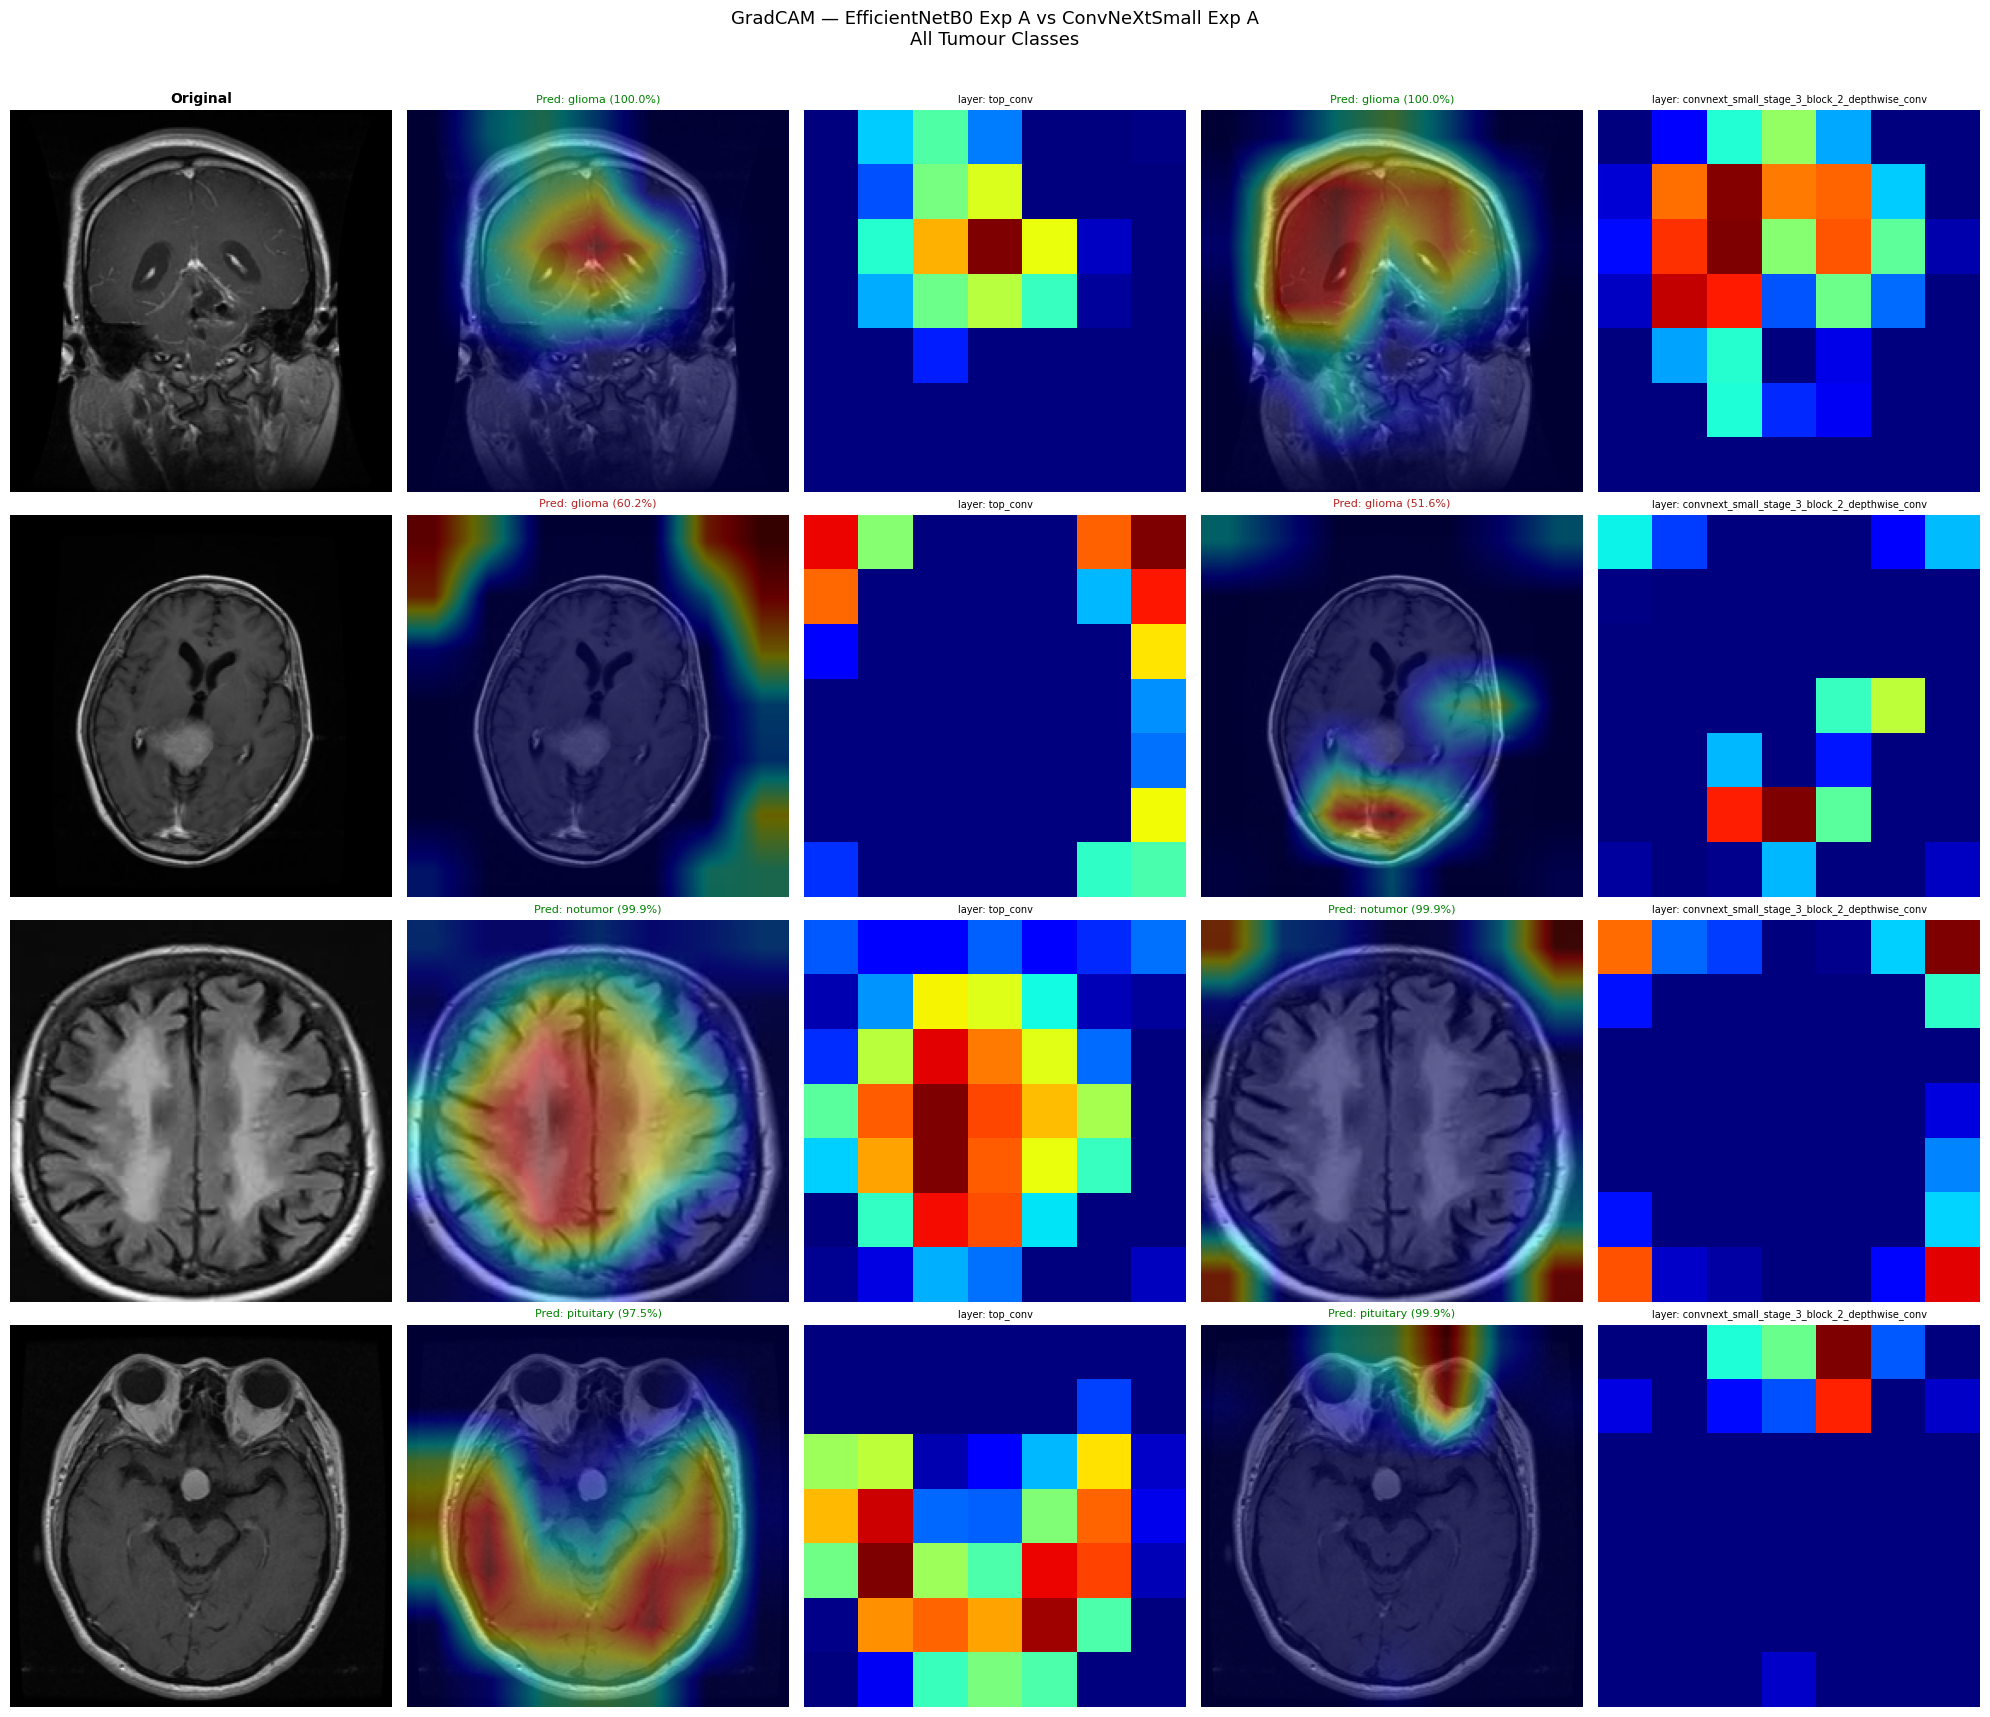

In [ ]:
from PIL import Image as PILImage

effnet_model   = models_loaded['EfficientNetB0 Exp A']
convnext_model = models_loaded['ConvNeXtSmall Exp A']

sample_paths = {}
for i, (path, label) in enumerate(zip(test_gen.filepaths, y_true)):
    cls = CLASS_NAMES[label]
    if cls not in sample_paths:
        sample_paths[cls] = path
    if len(sample_paths) == 4:
        break

fig, axes = plt.subplots(4, 5, figsize=(20, 17))
col_titles = ['Original', 'EfficientNetB0\nOverlay', 'EfficientNetB0\nHeatmap',
              'ConvNeXtSmall\nOverlay', 'ConvNeXtSmall\nHeatmap']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=10, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    path = sample_paths[cls]
    img = np.array(PILImage.open(path).convert('RGB').resize((224, 224)))

    eff_input  = np.expand_dims(effnet_preprocess(img.astype(np.float32)), axis=0)
    eff_probs  = effnet_model.predict(eff_input, verbose=0)
    eff_pred   = np.argmax(eff_probs)
    eff_heatmap, eff_conv = make_gradcam_heatmap(eff_input, effnet_model)
    eff_overlay = overlay_heatmap(img, eff_heatmap)

    cnx_input  = np.expand_dims(convnext_preprocess(img.astype(np.float32)), axis=0)
    cnx_probs  = convnext_model.predict(cnx_input, verbose=0)
    cnx_pred   = np.argmax(cnx_probs)
    cnx_heatmap, cnx_conv = make_gradcam_heatmap(cnx_input, convnext_model)
    cnx_overlay = overlay_heatmap(img, cnx_heatmap)

    def colour(pred, true): return 'green' if pred == CLASS_NAMES.index(true) else 'firebrick'

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(cls.capitalize(), fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(eff_overlay)
    axes[row, 1].set_title(f'Pred: {CLASS_NAMES[eff_pred]} ({eff_probs[0][eff_pred]:.1%})',
                           fontsize=8, color=colour(eff_pred, cls))
    axes[row, 1].axis('off')

    axes[row, 2].imshow(eff_heatmap, cmap='jet')
    axes[row, 2].set_title(f'layer: {eff_conv}', fontsize=7)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(cnx_overlay)
    axes[row, 3].set_title(f'Pred: {CLASS_NAMES[cnx_pred]} ({cnx_probs[0][cnx_pred]:.1%})',
                           fontsize=8, color=colour(cnx_pred, cls))
    axes[row, 3].axis('off')

    axes[row, 4].imshow(cnx_heatmap, cmap='jet')
    axes[row, 4].set_title(f'layer: {cnx_conv}', fontsize=7)
    axes[row, 4].axis('off')

plt.suptitle('GradCAM — EfficientNetB0 Exp A vs ConvNeXtSmall Exp A\nAll Tumour Classes',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


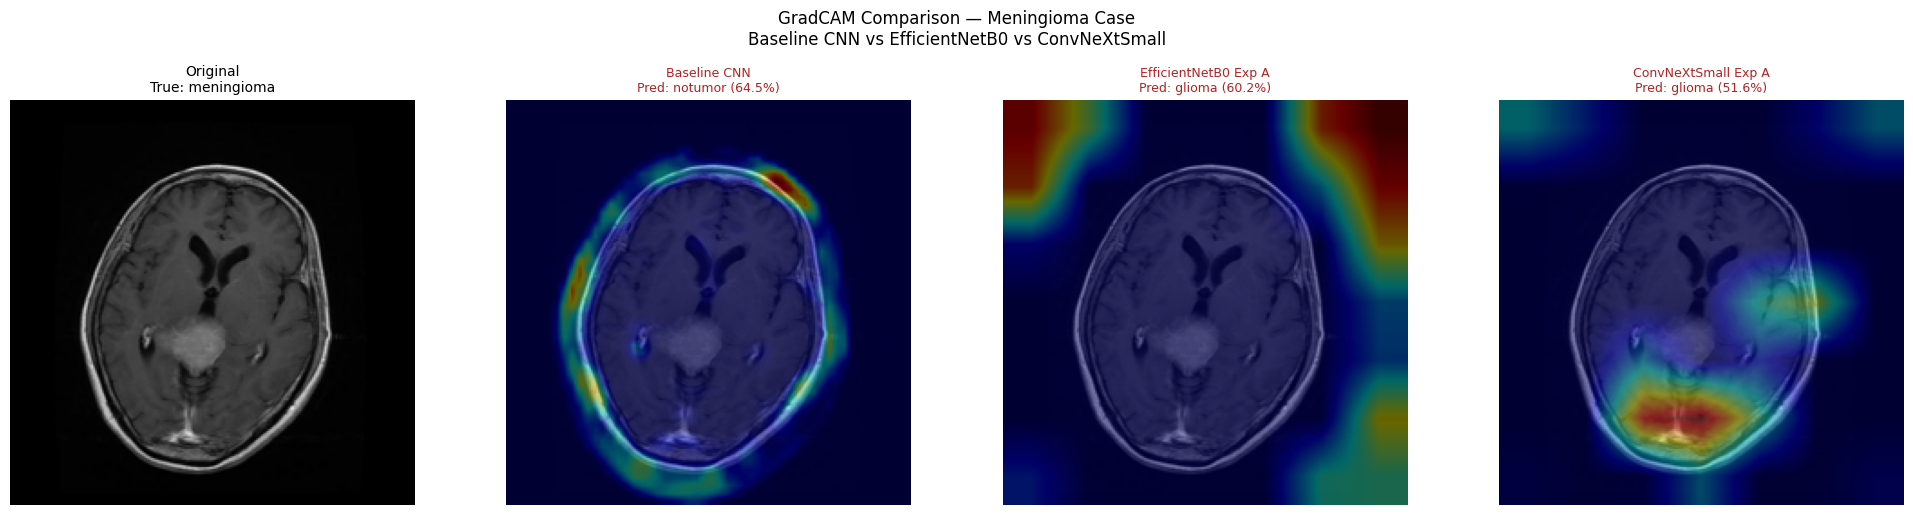

In [17]:
mening_idx = CLASS_NAMES.index('meningioma')
misclassified_mening = [
    (test_gen.filepaths[i], y_true[i], all_preds[best_name][i])
    for i in range(len(y_true))
    if y_true[i] == mening_idx and all_preds['Baseline CNN'][i] != mening_idx
]
if not misclassified_mening:
    misclassified_mening = [(test_gen.filepaths[i], y_true[i], all_preds[best_name][i])
                            for i in range(len(y_true)) if y_true[i] == mening_idx]

path, true_idx, _ = misclassified_mening[0]
img = np.array(PILImage.open(path).convert('RGB').resize((224, 224)))

compare_models = {
    'Baseline CNN':        (models_loaded['Baseline CNN'],        img.astype(np.float32) / 255.0),
    'EfficientNetB0 Exp A':(models_loaded['EfficientNetB0 Exp A'], effnet_preprocess(img.astype(np.float32))),
    'ConvNeXtSmall Exp A': (models_loaded['ConvNeXtSmall Exp A'],  convnext_preprocess(img.astype(np.float32))),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img)
axes[0].set_title(f'Original\nTrue: {CLASS_NAMES[true_idx]}', fontsize=10)
axes[0].axis('off')

for col, (mname, (mmodel, minput)) in enumerate(compare_models.items(), start=1):
    inp = np.expand_dims(minput, axis=0)
    heatmap, _ = make_gradcam_heatmap(inp, mmodel)
    overlaid = overlay_heatmap(img, heatmap)
    probs = mmodel.predict(inp, verbose=0)
    pred = np.argmax(probs)
    axes[col].imshow(overlaid)
    axes[col].set_title(
        f'{mname}\nPred: {CLASS_NAMES[pred]} ({probs[0][pred]:.1%})',
        fontsize=9,
        color='green' if pred == true_idx else 'firebrick'
    )
    axes[col].axis('off')

plt.suptitle('GradCAM Comparison — Meningioma Case\nBaseline CNN vs EfficientNetB0 vs ConvNeXtSmall',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 8. Statistical Significance Testing — Wilcoxon Signed-Rank Test

In [ ]:
from scipy.stats import wilcoxon

def correct_vector(preds, true): return (preds == true).astype(int)

cv = {name: correct_vector(preds, y_true) for name, preds in all_preds.items()}

pairs = [
    ('Baseline CNN',         'CNN Exp A'),
    ('CNN Exp A',            'EfficientNetB0 Exp A'),
    ('EfficientNetB0 Exp A', 'ConvNeXtSmall Exp A'),
    ('EfficientNetB0 Exp A', 'EfficientNetB0 Exp B'),
    ('ConvNeXtSmall Exp A',  'ConvNeXtSmall Exp B'),
]

print(f"{'Model A':<26} {'Model B':<26} {'Acc A':>7} {'Acc B':>7} {'p-value':>9} {'Significant':>12}")
print('-' * 95)
wilcoxon_results = []
for a, b in pairs:
    if a not in cv or b not in cv: continue
    ca, cb = cv[a], cv[b]

    diffs = ca.astype(float) - cb.astype(float)
    if np.all(diffs == 0):
        p = 1.0
    else:
        _, p = wilcoxon(ca, cb)
    acc_a = results_df.loc[a, 'Accuracy'] if a in results_df.index else float('nan')
    acc_b = results_df.loc[b, 'Accuracy'] if b in results_df.index else float('nan')
    sig = 'YES ***' if p < 0.001 else ('YES **' if p < 0.01 else ('YES *' if p < 0.05 else 'no'))
    print(f"{a:<26} {b:<26} {acc_a:>7.4f} {acc_b:>7.4f} {p:>9.4f} {sig:>12}")
    wilcoxon_results.append({'Model A': a, 'Model B': b, 'p-value': round(p, 4), 'Significant': p < 0.05})

print('\n* p<0.05  ** p<0.01  *** p<0.001')

Model A                    Model B                      Acc A   Acc B   p-value  Significant
-----------------------------------------------------------------------------------------------
Baseline CNN               CNN Exp A                   0.8583  0.8083    0.0008      YES ***
CNN Exp A                  EfficientNetB0 Exp A        0.8083  0.9131    0.0000      YES ***
EfficientNetB0 Exp A       ConvNeXtSmall Exp A         0.9131  0.9262    0.1590           no
EfficientNetB0 Exp A       EfficientNetB0 Exp B        0.9131  0.8988    0.0641           no
ConvNeXtSmall Exp A        ConvNeXtSmall Exp B         0.9262  0.9274    0.8415           no

* p<0.05  ** p<0.01  *** p<0.001


## 9. Cost-Sensitive Analysis

Cost Matrix (rows=true, cols=predicted):
            glioma  meningioma  notumor  pituitary
glioma         0.0         2.0      5.0        2.0
meningioma     2.0         0.0      5.0        2.0
notumor        1.0         1.0      0.0        1.0
pituitary      2.0         2.0      5.0        0.0

=== COST-WEIGHTED EVALUATION ===
                      Total Cost  Cost per Sample
ConvNeXtSmall Exp A        116.0           0.1381
ConvNeXtSmall Exp B        128.0           0.1524
EfficientNetB0 Exp A       143.0           0.1702
CNN Exp B (Otsu)           172.0           0.2048
EfficientNetB0 Exp B       180.0           0.2143
CNN Exp A                  349.0           0.4155
Baseline CNN               361.0           0.4298
ANN                        727.0           0.8655


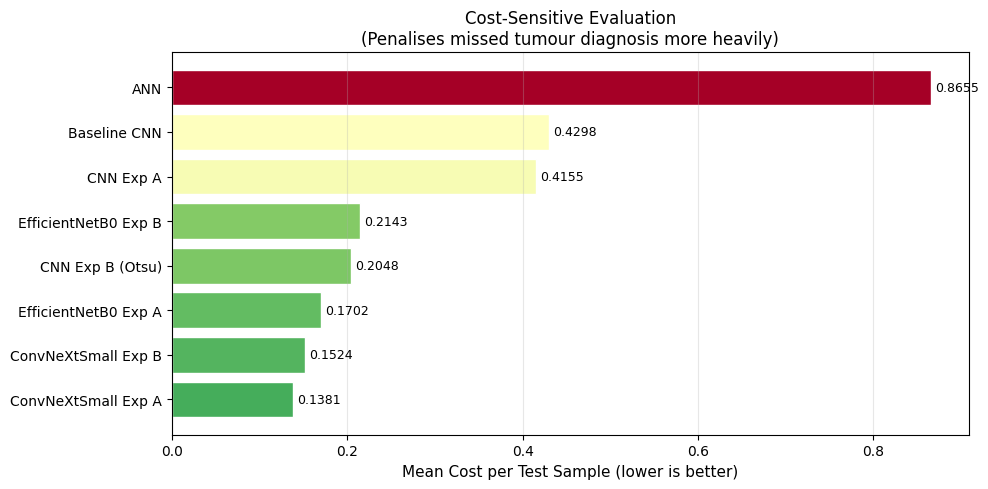


Note: class_weight=balanced was used during training, giving equal weight to all classes.
A cost-sensitive training regime (e.g. higher weight on tumour classes) would reduce
the Total Cost score further, at the expense of slightly lower overall accuracy.


In [ ]:
# Cost matrix: rows = true class, cols = predicted class
# CLASSES order: glioma=0, meningioma=1, notumor=2, pituitary=3
CLASS_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NO_TUMOUR_IDX = CLASS_IDX['notumor']

COST_MATRIX = np.array([
    #  glio  meni  notu  pitu   (predicted)
    [  0,    2,    5,    2  ],  # true=glioma
    [  2,    0,    5,    2  ],  # true=meningioma
    [  1,    1,    0,    1  ],  # true=notumor   (FP for tumour = low cost)
    [  2,    2,    5,    0  ],  # true=pituitary
], dtype=float)

print('Cost Matrix (rows=true, cols=predicted):')
cost_df = pd.DataFrame(COST_MATRIX, index=CLASS_NAMES, columns=CLASS_NAMES)
print(cost_df.to_string())
print()

cost_scores = {}
for name, preds in all_preds.items():
    total_cost = sum(COST_MATRIX[t, p] for t, p in zip(y_true, preds))
    max_possible = COST_MATRIX[y_true, :].max(axis=1).sum()
    normalised = total_cost / len(y_true)
    cost_scores[name] = {'Total Cost': int(total_cost), 'Cost per Sample': round(normalised, 4)}

cost_df_results = pd.DataFrame(cost_scores).T.sort_values('Cost per Sample')
print('=== COST-WEIGHTED EVALUATION ===')
print(cost_df_results.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cost_df_results.index, cost_df_results['Cost per Sample'],
               color=plt.cm.RdYlGn_r(cost_df_results['Cost per Sample'].values /
                                      cost_df_results['Cost per Sample'].max()),
               edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Mean Cost per Test Sample (lower is better)', fontsize=11)
ax.set_title('Cost-Sensitive Evaluation\n(Penalises missed tumour diagnosis more heavily)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('\nNote: class_weight=balanced was used during training, giving equal weight to all classes.')
print('A cost-sensitive training regime (e.g. higher weight on tumour classes) would reduce')
print('the Total Cost score further, at the expense of slightly lower overall accuracy.')

## 10. Radar Chart — Multi-Metric Model Comparison

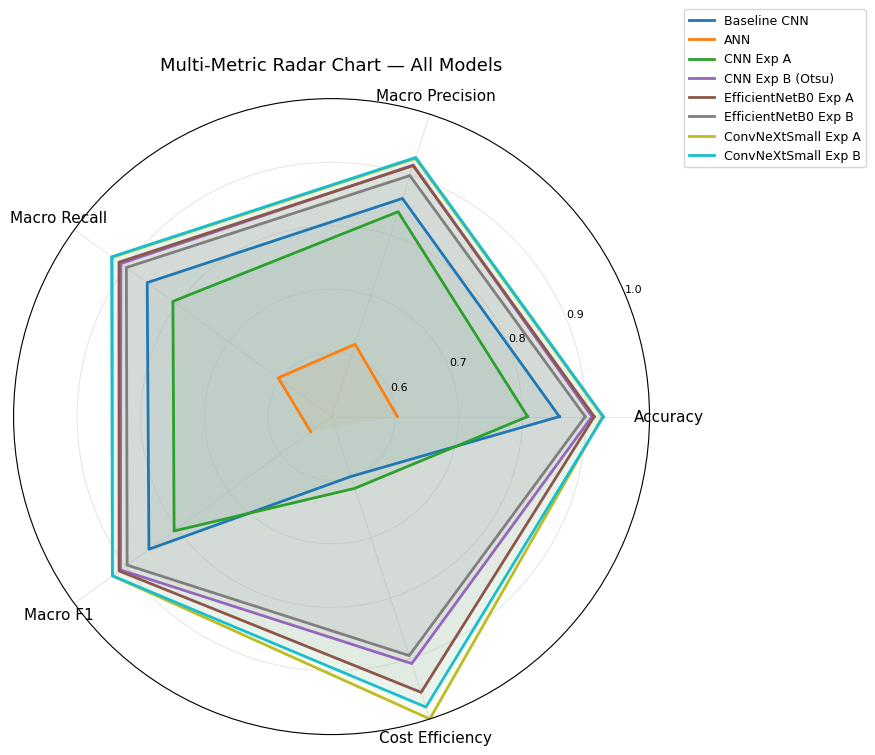

In [20]:
import matplotlib.patches as mpatches

metrics_cols = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
radar_df = results_df[metrics_cols].copy()

# Add cost efficiency column (1 - normalised cost, scaled to 0-1)
max_cost = cost_df_results['Cost per Sample'].max()
min_cost = cost_df_results['Cost per Sample'].min()
for name in radar_df.index:
    if name in cost_df_results.index:
        c = cost_df_results.loc[name, 'Cost per Sample']
        radar_df.loc[name, 'Cost Efficiency'] = round(1 - (c - min_cost) / (max_cost - min_cost + 1e-9), 4)
    else:
        radar_df.loc[name, 'Cost Efficiency'] = float('nan')

radar_df = radar_df.dropna()
all_metrics = list(radar_df.columns)
N = len(all_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colours = plt.cm.tab10(np.linspace(0, 1, len(radar_df)))
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for idx, (model_name, row) in enumerate(radar_df.iterrows()):
    vals = row.values.flatten().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, lw=2, color=colours[idx], label=model_name)
    ax.fill(angles, vals, alpha=0.07, color=colours[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(all_metrics, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], fontsize=8)
ax.set_title('Multi-Metric Radar Chart — All Models', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Summary Rankings — All Models

Final ranked table across all metrics, highlighting the best value in each column.

In [ ]:
full_summary = results_df.copy()
for name in full_summary.index:
    if name in cost_df_results.index:
        full_summary.loc[name, 'Cost/Sample'] = cost_df_results.loc[name, 'Cost per Sample']

full_summary = full_summary.sort_values('Macro F1', ascending=False)
print('=== COMPLETE MODEL RANKINGS ===')
print(full_summary.to_string())

full_summary.style\
    .highlight_max(
        subset=['Accuracy','Macro Precision','Macro Recall','Macro F1'],
        props='background-color: #c6efce; color: black;', axis=0)\
    .highlight_min(
        subset=['Cost/Sample'],
        props='background-color: #c6efce; color: black;', axis=0)\
    .format('{:.4f}')


=== COMPLETE MODEL RANKINGS ===
                      Accuracy  Macro Precision  Macro Recall  Macro F1  Cost/Sample
ConvNeXtSmall Exp A     0.9262           0.9270        0.9262    0.9260       0.1381
ConvNeXtSmall Exp B     0.9274           0.9284        0.9274    0.9259       0.1524
EfficientNetB0 Exp A    0.9131           0.9149        0.9131    0.9129       0.1702
CNN Exp B (Otsu)        0.9095           0.9159        0.9095    0.9102       0.2048
EfficientNetB0 Exp B    0.8988           0.8985        0.8988    0.8973       0.2143
Baseline CNN            0.8583           0.8607        0.8583    0.8549       0.4298
CNN Exp A               0.8083           0.8387        0.8083    0.8060       0.4155
ANN                     0.6036           0.6197        0.6036    0.5404       0.8655


,Accuracy,Macro Precision,Macro Recall,Macro F1,Cost/Sample
ConvNeXtSmall Exp A,0.9262,0.9270,0.9262,0.9260,0.1381
ConvNeXtSmall Exp B,0.9274,0.9284,0.9274,0.9259,0.1524
EfficientNetB0 Exp A,0.9131,0.9149,0.9131,0.9129,0.1702
CNN Exp B (Otsu),0.9095,0.9159,0.9095,0.9102,0.2048
EfficientNetB0 Exp B,0.8988,0.8985,0.8988,0.8973,0.2143
Baseline CNN,0.8583,0.8607,0.8583,0.8549,0.4298
CNN Exp A,0.8083,0.8387,0.8083,0.8060,0.4155
ANN,0.6036,0.6197,0.6036,0.5404,0.8655
